In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Time Series

- Moving Average
- Weighted Moving Average

- Target
    - MAPE < 5%

- Given x1,x2,. .. .xt
    - Predict xt+1, xt+2


- Seasonality 
    - Like during winters people buy more heaters and during summers people buy more fans

- Train and Test 
    - Train on past data 
    - Test on future data

- RMSE
- MAPE --> Mean Absolute Percentage Error --> error / actual value
- MAE


- Simple Forecasting Method
- Naive approach
- Seasonal Naive approach
- Drift method


Smoothing Based Methods:

1. Moving Average Forecasting
    . pd.date_range(start='2020-01-01', end='2020-12-31', freq='MS')

Simple Exponential Smoothing

Double Exponential Smoothing

Triple Exponential Smoothing

Terminology:
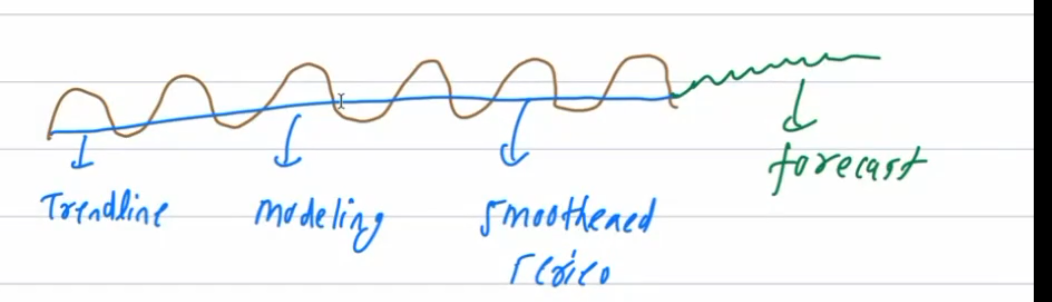

Trrendline, modeling and smoothened series mean same thing

SES --> memory of entire series + moreweight to recent forecast

yt+1 = alpha * yt + alpha*(1 - alpha) * yt-1 + alpha*(1 - alpha)^2 * yt-2 + ... + alpha*(1 - alpha)^(t-1) * y1


hack / thumb rule --> alpha = 1/2*seasonality

In [2]:


#import necessary things for exponential smoothing
from statsmodels.tsa.api import ExponentialSmoothing

model = sm.tsa.ExponentialSmoothing(train_data, trend='add', seasonal='add').fit()

ModuleNotFoundError: No module named 'statsmodels'

- ARIMA
- SARIMA
- SARIMAX


- ARIMA --> can be applied on stationary models only 

- Stationary model --> mean, variance, etc. are constant over time

how do we predict using arima-->

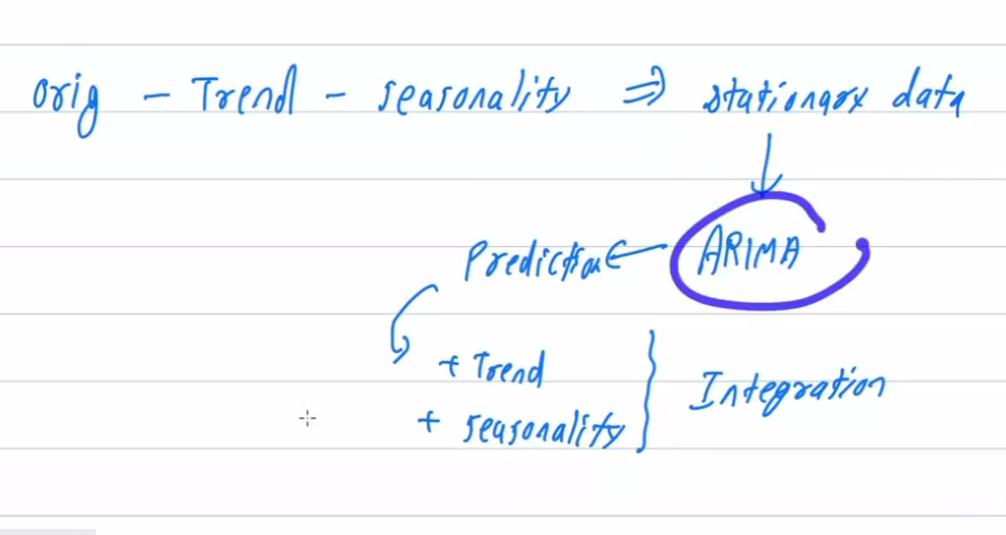


- Dicky-Fuller test --> works on time series

- Null Hypothesis: The time series has a unit root (non-stationary)
- Alternative Hypothesis: The time series is stationary

In [5]:
x = np.array([2540.0, 2667.0, 2156.0, 0, 3279.0, 2612.0, 2979.0,0,3733.0])
y = np.zeros(len(x))
for i in range(1, len(x)):
    y[i] = (x[i] + x[i-1]) / 2

print(y)


[   0.  2603.5 2411.5 1078.  1639.5 2945.5 2795.5 1489.5 1866.5]


In [12]:
date =  np.array(['2011-10-01', '2011-10-02', '2011-10-03', '2011-10-04', '2011-10-05', '2011-10-06', '2011-10-07', '2011-10-08', '2011-10-09', '2011-10-10'])

temp =  np.array([90.55611463896416, 93.40578579065783, 93.77126836890373, 86.8096061129281, 88.99632608774843, 86.18768278207911, 87.71959680981328, 92.41076163005184, 90.45799573572515, 92.24789020415145])
#temperatures is the given dataframe consisting of columns {date: (datetime format, 'yyyy-mm-dd'), temp: (float)}

# Set date as the index and sort the index for df temperature
temperatures = pd.DataFrame({'date': date, 'temp': temp})
temperatures['date'] = pd.to_datetime(temperatures['date'])
temperatures_ind = temperatures.set_index('date').sort_index()

print(temperatures_ind)

# Average temperature for all the days whose temperature is provided in the dataframe for the years 2010 and 2011.

print(temperatures_ind['2010':'2011'].mean())

# emperature is provided in the dataframe inbetween August-2010 and February-2011 inclusive.

print(temp['2010-08':'2011-02'].mean())


                 temp
date                 
2011-10-01  90.556115
2011-10-02  93.405786
2011-10-03  93.771268
2011-10-04  86.809606
2011-10-05  88.996326
2011-10-06  86.187683
2011-10-07  87.719597
2011-10-08  92.410762
2011-10-09  90.457996
2011-10-10  92.247890
temp    90.256303
dtype: float64


TypeError: slice indices must be integers or None or have an __index__ method

In [13]:
import numpy as np

x = np.array([ 330, 11500, 16500, 914, 796, 353, 6470, 219, 389, 805, 256, 919, 398, 900, 496, -6240, 948, 711, 306, 777, 719, 545, 248])

def replace_outliers(x):
    mean = np.mean(x)
    std = np.std(x)
    median = np.median(x)
    for i in range(len(x)):
        if x[i] < mean - 2*std or x[i] > mean + 2*std:
            x[i] = median
    return x

x = replace_outliers(x)
print(x)

[  330   711   711   914   796   353  6470   219   389   805   256   919
   398   900   496 -6240   948   711   306   777   719   545   248]


In [15]:
x = 6/11 + 6.20/13 + 2.66/6 + 2.862/5
x = x*100
x = x/4
print(x)


50.9527738927739


To remove trend:
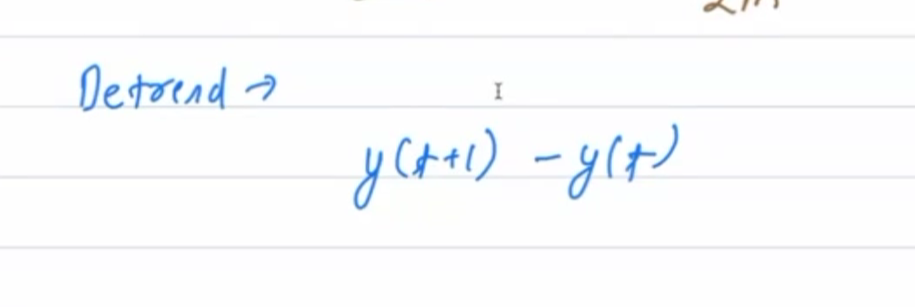

do this for every value

Do the ducky fuller test, if it says, data is not stationary, do it again

- Deseasonality:

    - just like de trend , where we remove previous value , if seasonality is M , for every value, we do yt = yt - y(t-M)

In [16]:
plt.rcParams['figure.figsize'] = (20,6)

In [1]:
import numpy as np
import pandas as pd
x = np.array([1,2,3,4,5])
y = np.diff(x, n=1)
print(y)

[1 1 1 1]


- Calculating seasonality 
    - Auto correlation

In [57]:
import matplotlib.pyplot as plt
df_mobile_sales = pd.read_excel("mobilesales.xlsx")


In [58]:
df_mobile_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    217 non-null    datetime64[ns]
 1   Sales   198 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.5 KB


<Axes: >

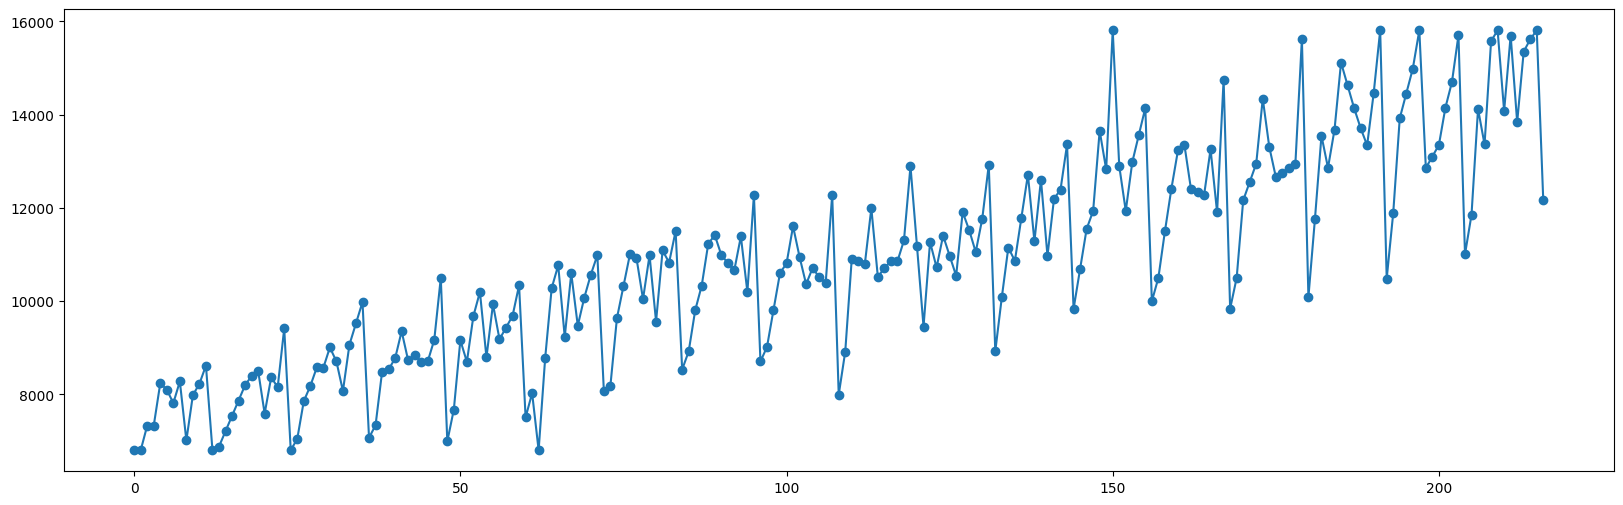

In [59]:
df_mobile_sales.Sales = df_mobile_sales.Sales.interpolate(method='linear')

# anomalies - clip quantiles
df_mobile_sales.Sales = df_mobile_sales.Sales.clip(upper=df_mobile_sales.Sales.quantile(0.98), lower=df_mobile_sales.Sales.quantile(0.02))

# plot
df_mobile_sales.Sales.plot(style='-o', figsize=(20,6))

<Axes: >

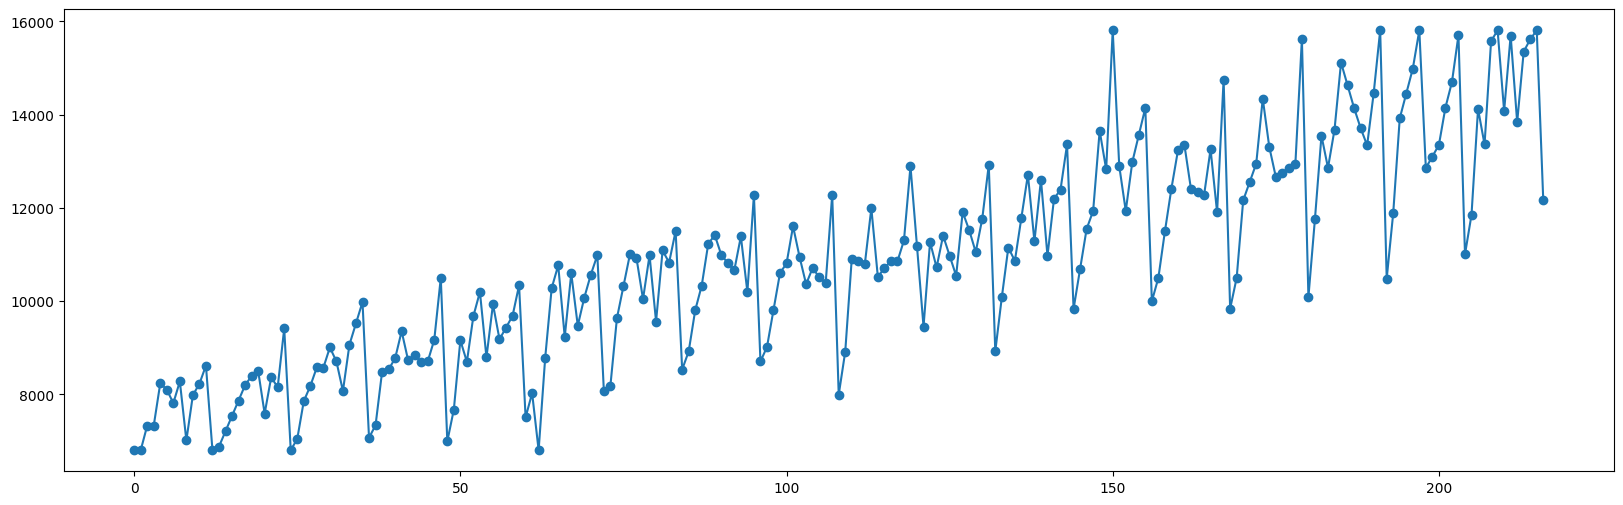

In [60]:
df_mobile_sales.Sales.plot(style='-o', figsize=(20,6))

In [61]:
mobile_sales = df_mobile_sales

In [62]:
train_max_date = mobile_sales.index[-12]
train_x = mobile_sales.loc[mobile_sales.index < mobile_sales.index[-12]].copy()
test_x = mobile_sales.loc[mobile_sales.index >= mobile_sales.index[-12]].copy()

test_x

,DATE,Sales
205,2018-02-01,11852.0
206,2018-03-01,14123.0
207,2018-04-01,13360.0
208,2018-05-01,15576.0
209,2018-06-01,15809.4
210,2018-07-01,14080.0
211,2018-08-01,15697.0
212,2018-09-01,13838.0
213,2018-10-01,15351.0
214,2018-11-01,15615.0


In [63]:
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

MAE : 1692.467
RMSE : 1875.03
MAPE: 0.115


array([15809.4, 12856. , 13102.5, 13349. , 14150. , 14698. , 15704. ,
       11005. , 13802.3, 13503.8, 12770.4, 13358.8, 13211. , 13113.4,
       13227.7, 13184. , 13175.1, 13195.6, 13184.9, 13185.2])

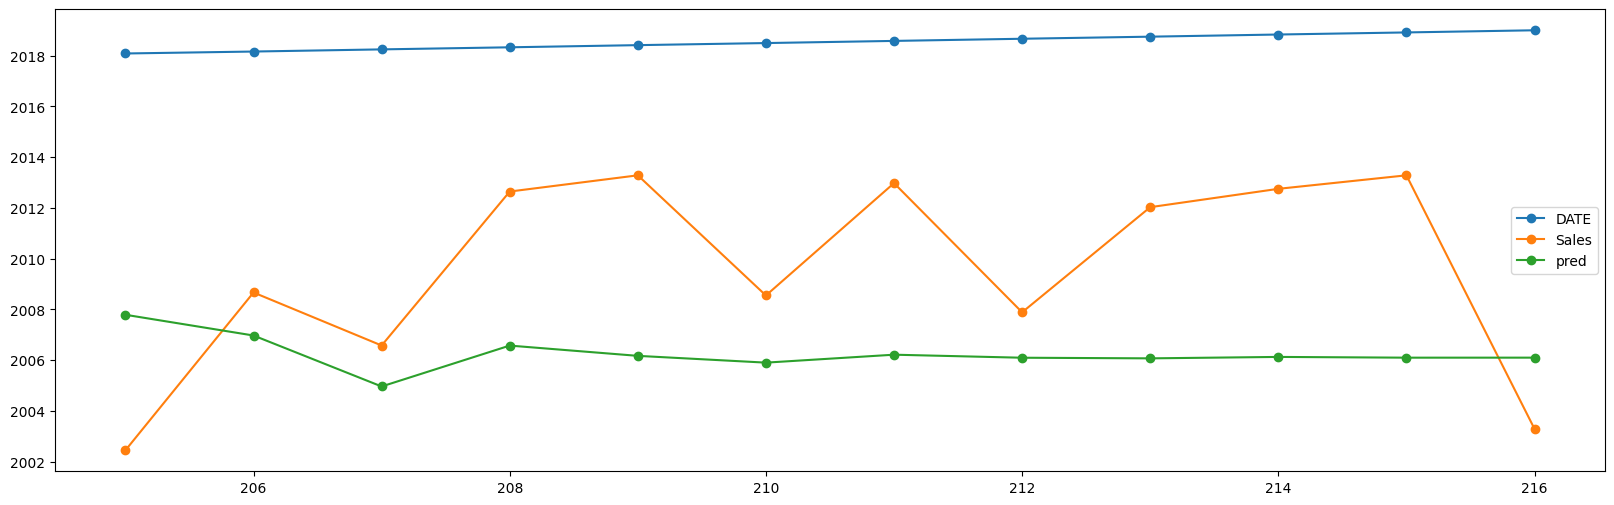

In [64]:
import numpy as np

df = mobile_sales.copy()
pd.DataFrame(index = pd.date_range(start=df.index[-1], periods=12,freq='MS'))
df = pd.concat([
    df,
    pd.DataFrame(index=pd.date_range(start=df.index[-1], periods=13, freq='MS')[1:])
])
df = train_x.copy()


df = pd.concat([df, pd.DataFrame(index = pd.date_range(start=df.index[-1], periods=12,freq='MS')[1:])])
pred = df.Sales.dropna().values

for i in range(12):
  pred = np.append(pred, pred[-3:].mean())

test_x['pred'] = pred[-12:]
test_x.plot(style='-o')
performance(test_x['Sales'], test_x['pred'])
pred = df.Sales.dropna().values

for i in range(12):
  pred = np.append(pred, pred[-3:].mean())

pred[-20:]
pred = pred.round(1)
pred[-20:]

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


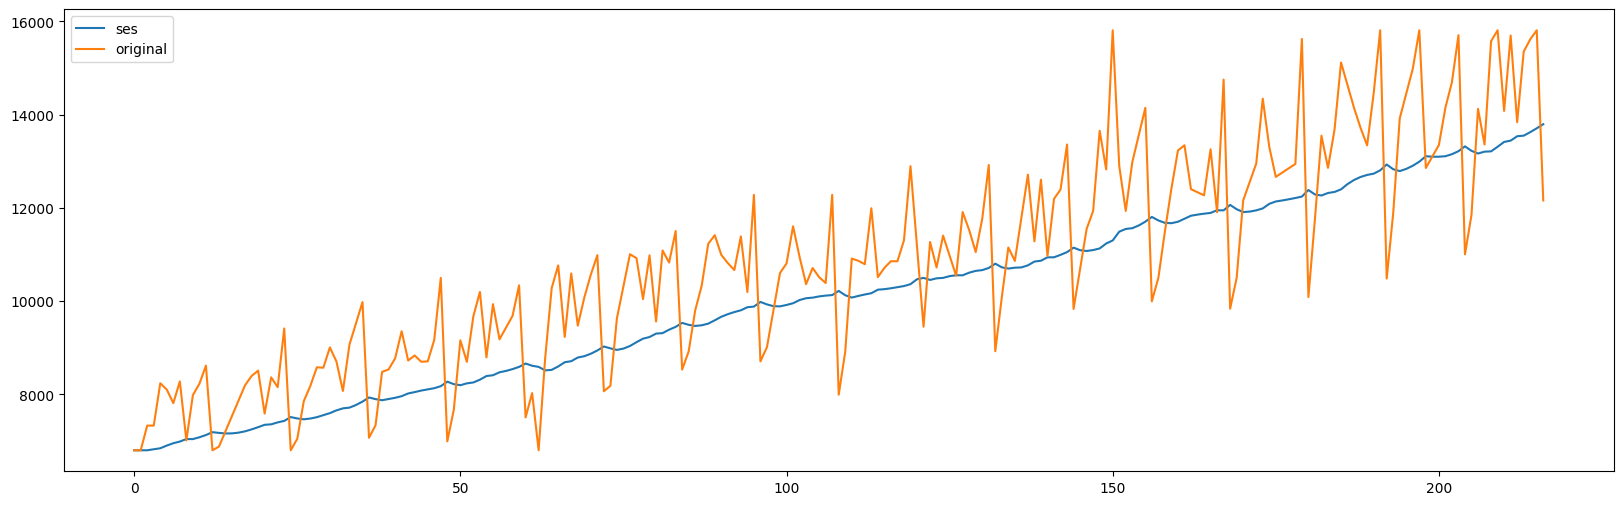

In [65]:
import statsmodels.api as sm
model = pd.Series(sm.tsa.SimpleExpSmoothing(mobile_sales.Sales).fit(smoothing_level=1/(2*12)).fittedvalues)

model.plot(label='ses')
mobile_sales.Sales.plot(label='original')
plt.legend()

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\util\_decorators.py:213: EstimationWarning: Model has no free parameters to estimate. Set optimized=False to suppress this warning
  return func(*args, **kwargs)


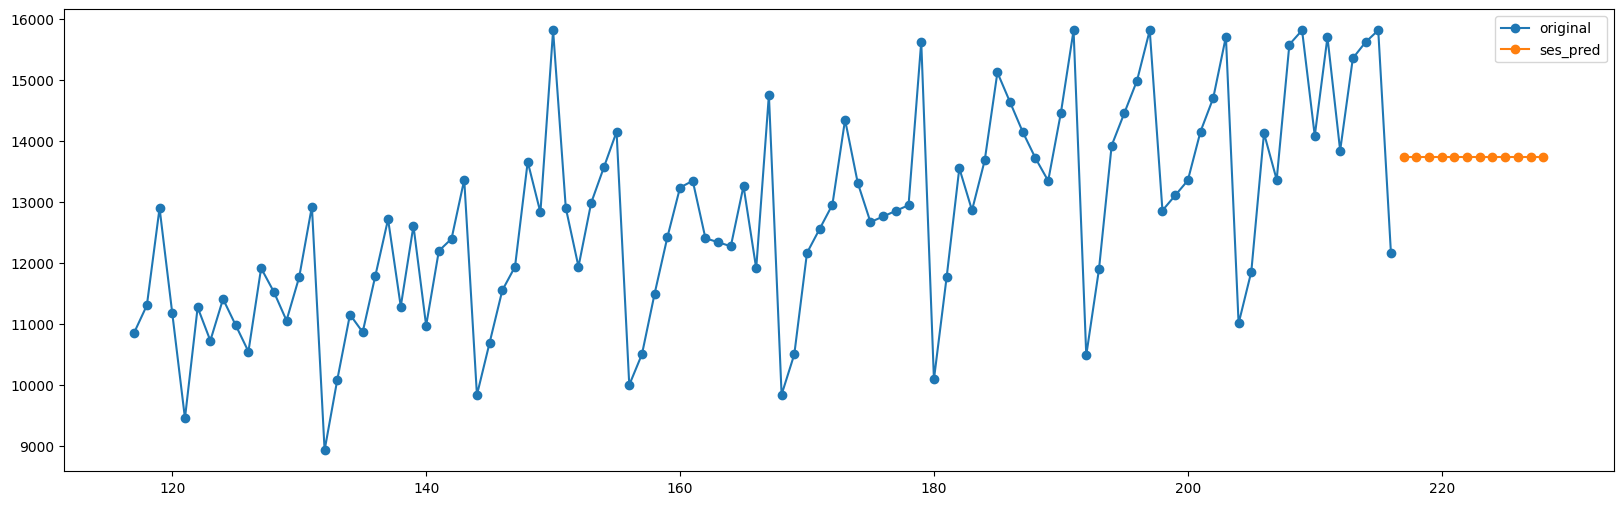

In [72]:
model = sm.tsa.SimpleExpSmoothing(mobile_sales.Sales).fit(smoothing_level=1/(2*12))
pred = model.forecast(steps = 12)

mobile_sales.Sales.tail(100).plot(label='original', style='-o')

pred.plot(label='ses_pred', style='-o')
plt.legend()

<Axes: >

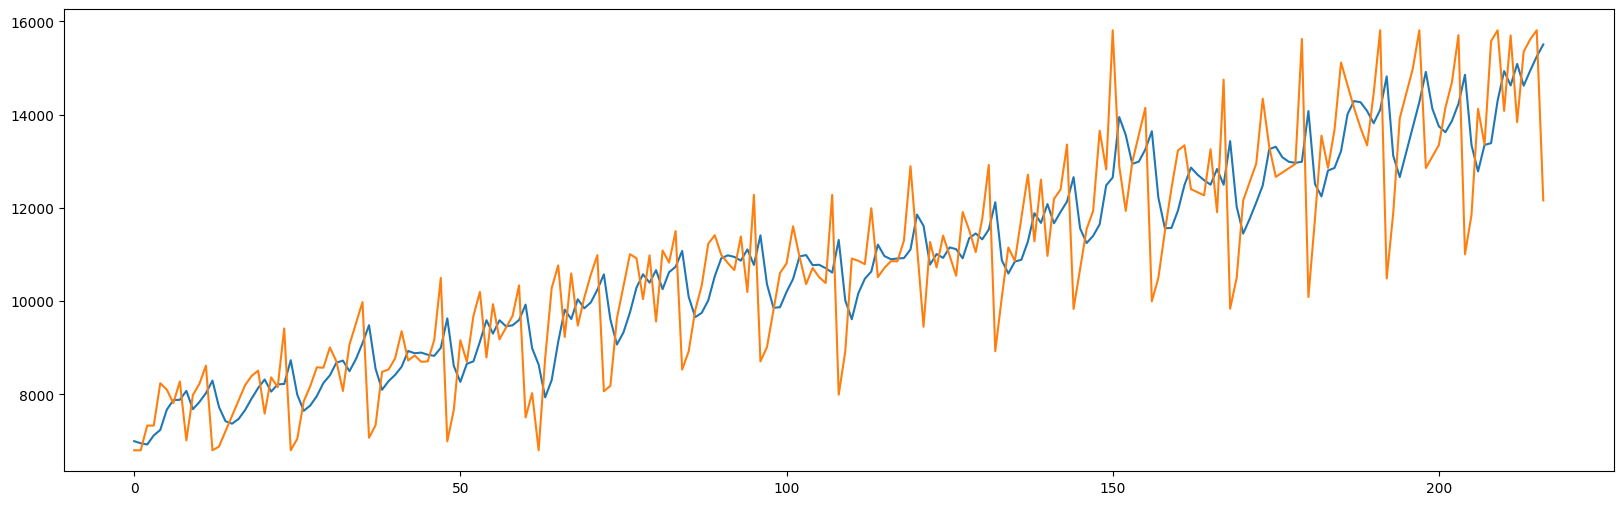

In [76]:
model = sm.tsa.ExponentialSmoothing(mobile_sales.Sales, trend='add').fit(smoothing_level=0.4)
model.fittedvalues.plot()
mobile_sales.Sales.plot()

<Axes: >

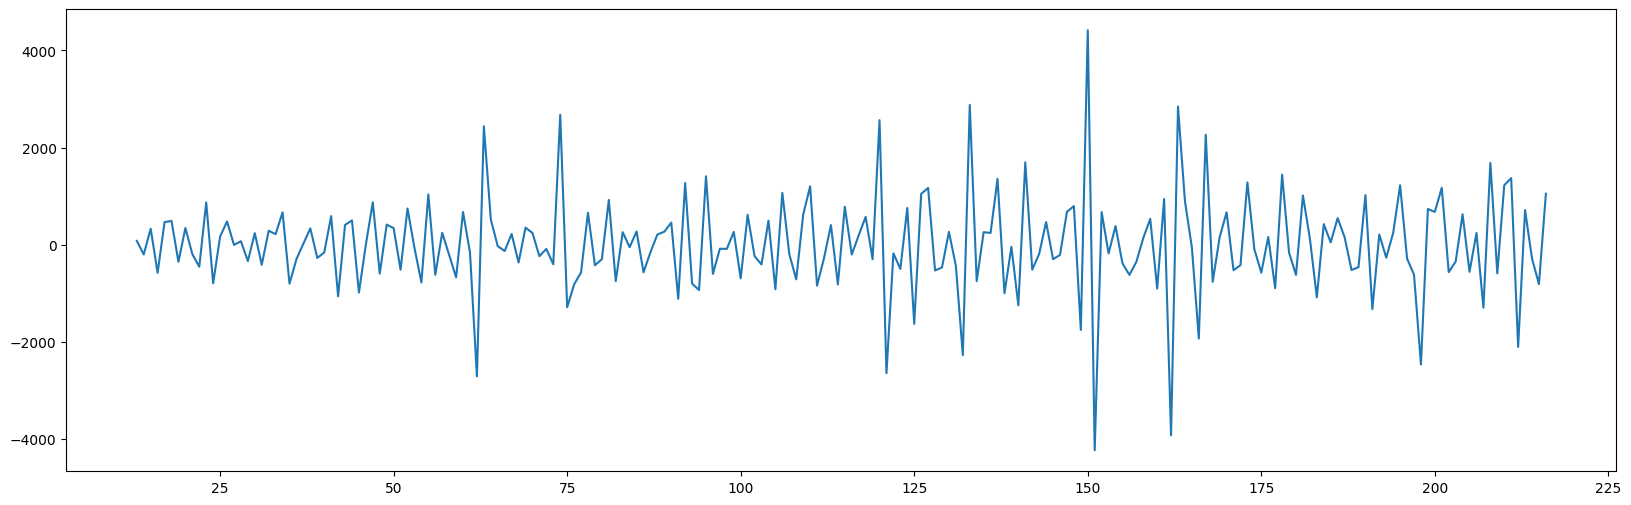

In [67]:
df_mobile_sales = df_mobile_sales.diff()
df_mobile_sales.Sales.shift(1).head()
stationary = mobile_sales.Sales.diff(1).diff(12)
stationary.plot()

In [68]:
lag = 1
np.corrcoef(mobile_sales.Sales[lag:], mobile_sales.Sales.shift(lag)[lag:])[0][1]

np.float64(0.8002851477229682)

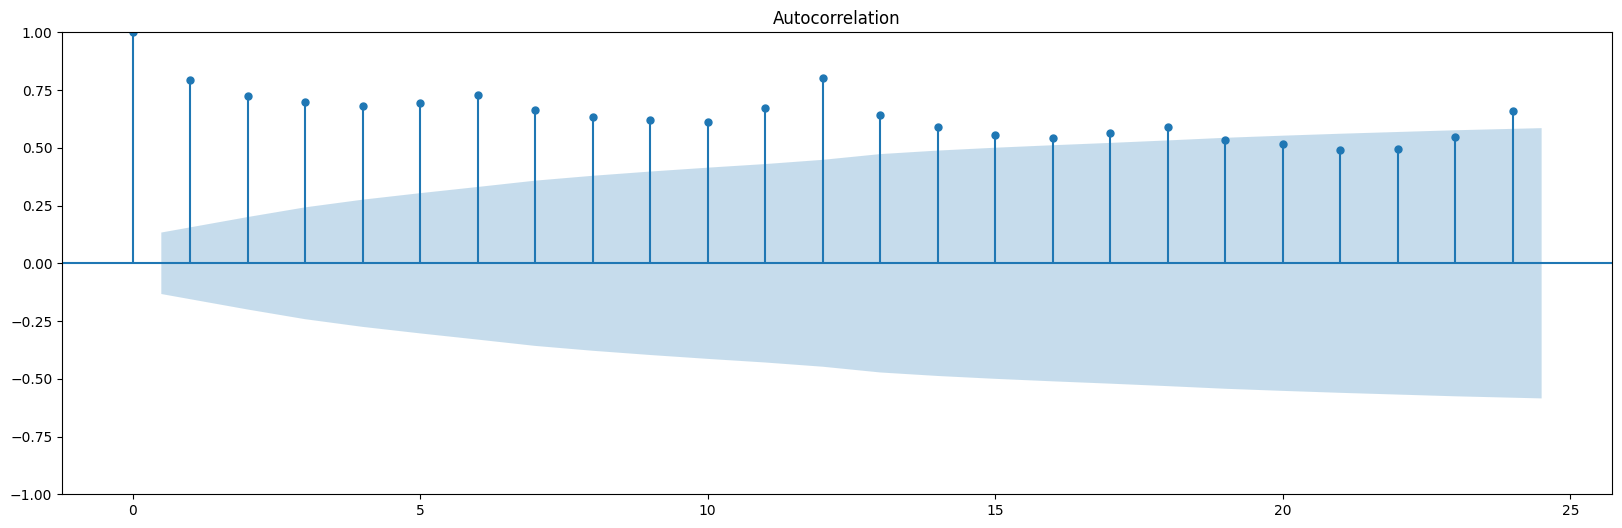

In [69]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(mobile_sales.Sales);

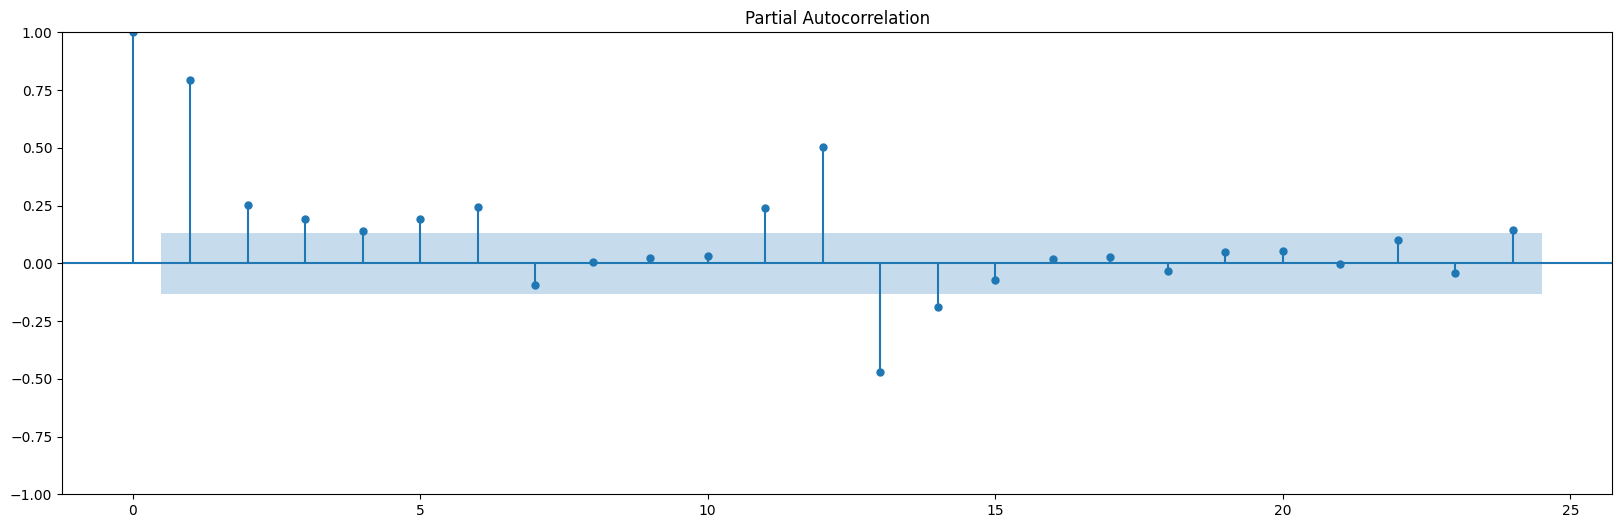

In [70]:
plot_pacf(mobile_sales.Sales);

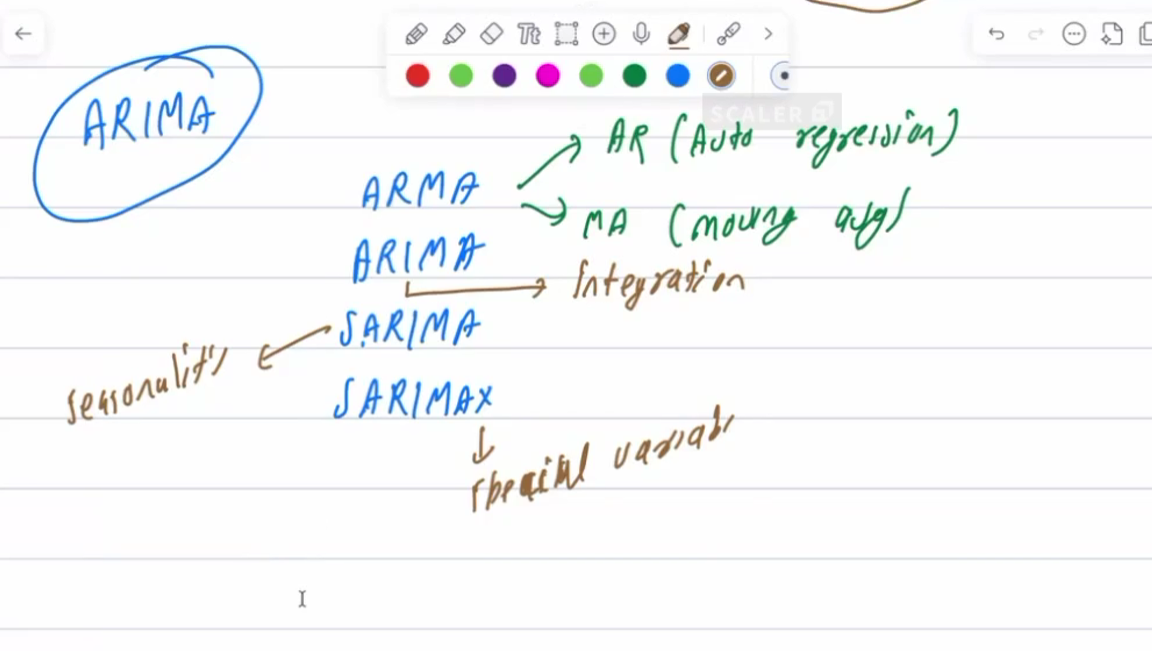

In [38]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
mobile_sales = pd.read_excel("mobilesales.xlsx")


train_max_date = mobile_sales.index[-12]
train_x = mobile_sales.loc[mobile_sales.index < mobile_sales.index[-12]].copy()
test_x = mobile_sales.loc[mobile_sales.index >= mobile_sales.index[-12]].copy()

test_x

,DATE,Sales
205,2018-02-01,11852.0
206,2018-03-01,14123.0
207,2018-04-01,13360.0
208,2018-05-01,15576.0
209,2018-06-01,16021.0
210,2018-07-01,14080.0
211,2018-08-01,15697.0
212,2018-09-01,13838.0
213,2018-10-01,15351.0
214,2018-11-01,15615.0


In [39]:
train_x.head()

,DATE,Sales
0,2001-01-01,6519.0
1,2001-02-01,6654.0
2,2001-03-01,7332.0
3,2001-04-01,7332.0
4,2001-05-01,8240.0


In [40]:
train_x = train_x.dropna()
test_x = test_x.dropna()

In [41]:
def adf_test(dataset):
   pvalue = sm.tsa.stattools.adfuller(dataset)[1]
   if pvalue <= 0.05:
      print('Sequence is stationary')
   else:
      print('Sequence is not stationary')

adf_test(train_x.Sales)

Sequence is not stationary


In [42]:
train_x_st = train_x.diff(1)
train_x_st = train_x_st.dropna()

In [43]:
adf_test(train_x_st['Sales'])

Sequence is stationary


In [44]:
import statsmodels as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import (
    mean_squared_error as mse,
    mean_absolute_error as mae,
    mean_absolute_percentage_error as mape
)

# Creating a function to print values of all these metrics.
def performance(actual, predicted):
    print('MAE :', round(mae(actual, predicted), 3))
    print('RMSE :', round(mse(actual, predicted)**0.5, 3))
    print('MAPE:', round(mape(actual, predicted), 3))

In [81]:
model = SARIMAX(train_x_st.Sales, order=(3,1,3), seasonal_order=(1,1,1,12)).fit()

In [82]:
# Forecast 12 steps ahead
pred = model.forecast(steps=12)

# Align forecast index with test set
pred.index = test_x.index

# Restore original scale
test_x['pred'] = pred.cumsum() + train_x.Sales.iloc[-1]

# Drop NaNs together
test_clean = test_x[['Sales', 'pred']].dropna()

# Evaluate 
performance(test_clean['Sales'], test_clean['pred'])


MAE : 1216.531
RMSE : 1455.956
MAPE: 0.084


- The X in SARIMAX
  - X is the exogenous variables
  - Also called as X-factor, like holidays in sales or cyclone in temperature or Kohli hitting sixes in viewrship of cricket games 

in SARIMAX, we add this as a feature, and in code we put exog = "feature-name" in the fit function

In [96]:
dates = ['2018-01-01', '2018-01-02', '2018-01-03', '2018-01-04', '2018-01-05', '2018-01-06', '2018-01-07', '2018-01-08', '2018-01-09', '2018-01-10', '2018-01-11', '2018-01-12', '2018-01-13', '2018-01-14', '2018-01-15', '2018-01-16', '2018-01-17', '2018-01-18', '2018-01-19', '2018-01-20', '2018-01-21', '2018-01-22', '2018-01-23', '2018-01-24', '2018-01-25', '2018-01-26', '2018-01-27', '2018-01-28', '2018-01-29', '2018-01-30', '2018-01-31', '2018-02-01', '2018-02-02', '2018-02-03', '2018-02-04', '2018-02-05', '2018-02-06', '2018-02-07', '2018-02-08', '2018-02-09', '2018-02-10', '2018-02-11', '2018-02-12', '2018-02-13', '2018-02-14', '2018-02-15', '2018-02-16', '2018-02-17', '2018-02-18', '2018-02-19', '2018-02-20', '2018-02-21', '2018-02-22', '2018-02-23', '2018-02-24', '2018-02-25', '2018-02-26', '2018-02-27', '2018-02-28', '2018-03-01', '2018-03-02', '2018-03-03', '2018-03-04', '2018-03-05', '2018-03-06', '2018-03-07', '2018-03-08', '2018-03-09', '2018-03-10', '2018-03-11', '2018-03-12', '2018-03-13', '2018-03-14', '2018-03-15', '2018-03-16', '2018-03-17', '2018-03-18', '2018-03-19', '2018-03-20', '2018-03-21', '2018-03-22', '2018-03-23', '2018-03-24', '2018-03-25', '2018-03-26', '2018-03-27', '2018-03-28', '2018-03-29', '2018-03-30', '2018-03-31', '2018-04-01', '2018-04-02', '2018-04-03', '2018-04-04', '2018-04-05', '2018-04-06', '2018-04-07', '2018-04-08', '2018-04-09', '2018-04-10', '2018-04-11', '2018-04-12', '2018-04-13', '2018-04-14', '2018-04-15', '2018-04-16', '2018-04-17', '2018-04-18', '2018-04-19', '2018-04-20', '2018-04-21', '2018-04-22', '2018-04-23', '2018-04-24', '2018-04-25', '2018-04-26', '2018-04-27', '2018-04-28', '2018-04-29', '2018-04-30', '2018-05-01', '2018-05-02', '2018-05-03', '2018-05-04', '2018-05-05', '2018-05-06', '2018-05-07', '2018-05-08', '2018-05-09', '2018-05-10', '2018-05-11', '2018-05-12', '2018-05-13', '2018-05-14', '2018-05-15', '2018-05-16', '2018-05-17', '2018-05-18', '2018-05-19', '2018-05-20', '2018-05-21', '2018-05-22', '2018-05-23', '2018-05-24', '2018-05-25', '2018-05-26', '2018-05-27', '2018-05-28', '2018-05-29', '2018-05-30', '2018-05-31', '2018-06-01', '2018-06-02', '2018-06-03', '2018-06-04', '2018-06-05', '2018-06-06', '2018-06-07', '2018-06-08', '2018-06-09', '2018-06-10', '2018-06-11', '2018-06-12', '2018-06-13', '2018-06-14', '2018-06-15', '2018-06-16', '2018-06-17', '2018-06-18', '2018-06-19', '2018-06-20', '2018-06-21', '2018-06-22', '2018-06-23', '2018-06-24', '2018-06-25', '2018-06-26', '2018-06-27', '2018-06-28', '2018-06-29', '2018-06-30', '2018-07-01', '2018-07-02', '2018-07-03', '2018-07-04', '2018-07-05', '2018-07-06', '2018-07-07', '2018-07-08', '2018-07-09', '2018-07-10', '2018-07-11', '2018-07-12', '2018-07-13', '2018-07-14', '2018-07-15', '2018-07-16', '2018-07-17', '2018-07-18', '2018-07-19', '2018-07-20', '2018-07-21', '2018-07-22', '2018-07-23', '2018-07-24', '2018-07-25', '2018-07-26', '2018-07-27', '2018-07-28', '2018-07-29', '2018-07-30', '2018-07-31', '2018-08-01', '2018-08-02', '2018-08-03', '2018-08-04', '2018-08-05', '2018-08-06', '2018-08-07', '2018-08-08', '2018-08-09', '2018-08-10', '2018-08-11', '2018-08-12', '2018-08-13', '2018-08-14', '2018-08-15', '2018-08-16', '2018-08-17', '2018-08-18', '2018-08-19', '2018-08-20', '2018-08-21', '2018-08-22', '2018-08-23', '2018-08-24', '2018-08-25', '2018-08-26', '2018-08-27', '2018-08-28', '2018-08-29', '2018-08-30', '2018-08-31', '2018-09-01', '2018-09-02', '2018-09-03', '2018-09-04', '2018-09-05', '2018-09-06', '2018-09-07', '2018-09-08', '2018-09-09', '2018-09-10', '2018-09-11', '2018-09-12', '2018-09-13', '2018-09-14', '2018-09-15', '2018-09-16', '2018-09-17', '2018-09-18', '2018-09-19', '2018-09-20', '2018-09-21', '2018-09-22', '2018-09-23', '2018-09-24', '2018-09-25', '2018-09-26', '2018-09-27', '2018-09-28', '2018-09-29', '2018-09-30', '2018-10-01', '2018-10-02', '2018-10-03', '2018-10-04', '2018-10-05', '2018-10-06', '2018-10-07', '2018-10-08', '2018-10-09', '2018-10-10', '2018-10-11', '2018-10-12', '2018-10-13', '2018-10-14', '2018-10-15', '2018-10-16', '2018-10-17', '2018-10-18', '2018-10-19', '2018-10-20', '2018-10-21', '2018-10-22', '2018-10-23', '2018-10-24', '2018-10-25', '2018-10-26', '2018-10-27', '2018-10-28', '2018-10-29', '2018-10-30', '2018-10-31', '2018-11-01', '2018-11-02', '2018-11-03', '2018-11-04', '2018-11-05', '2018-11-06', '2018-11-07', '2018-11-08', '2018-11-09', '2018-11-10', '2018-11-11', '2018-11-12', '2018-11-13', '2018-11-14', '2018-11-15', '2018-11-16', '2018-11-17', '2018-11-18', '2018-11-19', '2018-11-20', '2018-11-21', '2018-11-22', '2018-11-23', '2018-11-24', '2018-11-25', '2018-11-26', '2018-11-27', '2018-11-28', '2018-11-29', '2018-11-30', '2018-12-01', '2018-12-02', '2018-12-03', '2018-12-04', '2018-12-05', '2018-12-06', '2018-12-07', '2018-12-08']
units_sold = [147, 342, 380, 292, 114, 311, 339, 90, 446, 302, 149, 362, 165, 103, 90, 473, 24, 391, 472, 427, 294, 169, 116, 378, 62, 296, 33, 89, 485, 224, 404, 281, 137, 238, 381, 335, 121, 182, 6, 376, 46, 445, 353, 377, 61, 119, 245, 302, 49, 72, 350, 376, 254, 432, 80, 120, 151, 167, 44, 123, 390, 456, 410, 64, 155, 406, 6, 326, 199, 32, 24, 76, 174, 376, 325, 517, 255, 81, 70, 339, 395, 484, 408, 386, 362, 353, 207, 52, 435, 360, 430, 410, 491, 168, 378, 120, 308, 486, 67, 287, 258, 354, 319, 123, 35, 235, 304, 342, 407, 36, 257, 270, 1, 140, 456, 466, 6, 8, 446, 451, 44, 430, 431, 256, 470, 400, 231, 178, 435, 109, 405, 450, 375, 278, 136, 272, 444, 111, 109, 232, 285, 492, 162, 10, 86, 180, 302, 198, 463, 341, 351, 155, 47, 90, 202, 404, 52, 483, 510, 500, 413, 164, 496, 212, 162, 302, 103, 362, 16, 495, 181, 9, 63, 311, 424, 398, 170, 325, 236, 188, 396, 457, 106, 355, 299, 319, 308, 220, 253, 440, 373, 493, 475, 387, 376, 240, 184, 269, 406, 180, 374, 228, 378, 322, 380, 211, 309, 124, 37, 42, 367, 173, 252, 278, 518, 163, 102, 304, 197, 206, 266, 24, 134, 255, 453, 228, 139, 195, 395, 428, 414, 246, 299, 315, 321, 289, 35, 38, 314, 97, 77, 359, 299, 375, 410, 228, 223, 16, 454, 62, 96, 270, 65, 477, 392, 506, 333, 164, 46, 184, 149, 62, 387, 187, 358, 27, 328, 411, 201, 45, 231, 98, 237, 46, 391, 69, 452, 239, 267, 193, 486, 70, 8, 14, 299, 487, 412, 453, 112, 12, 279, 459, 20, 429, 86, 109, 132, 133, 403, 30, 169, 377, 486, 407, 306, 185, 457, 408, 280, 384, 119, 92, 40, 318, 120, 372, 44, 115, 214, 452, 41, 417, 102, 44, 1, 247, 178, 240, 80, 388, 209, 439, 345, 125, 243, 381, 377, 196, 504, 352, 322, 336]

In [97]:
df = pd.DataFrame({'dates':dates,'units_sold':units_sold})
df['dates'] = pd.to_datetime(df['dates'])

In [98]:
df['month'] = df['dates'].dt.month

In [99]:
df['average_sales'] = df.groupby('month')['units_sold'].transform('mean')

In [100]:
df.head()

,dates,units_sold,month,average_sales
0,2018-01-01,147,1,257.064516
1,2018-01-02,342,1,257.064516
2,2018-01-03,380,1,257.064516
3,2018-01-04,292,1,257.064516
4,2018-01-05,114,1,257.064516


In [101]:
ans = df[['month', 'average_sales']].drop_duplicates()

In [105]:
ans = ans.reset_index(drop=True)

In [106]:
ans

,month,average_sales
0,1,257.064516
1,2,217.857143
2,3,266.000000
3,4,268.633333
4,5,279.548387
5,6,262.300000
6,7,293.064516
7,8,246.451613
8,9,234.066667
9,10,242.870968


In [119]:
Start_date = ['2000-01-01', '2000-01-02', '2000-01-03', '2000-01-04', '2000-01-05', '2000-01-06', '2000-01-07', '2000-01-08', '2000-01-09', '2000-01-10', '2000-01-11', '2000-01-12', '2000-01-13', '2000-01-14', '2000-01-15', '2000-01-16', '2000-01-17', '2000-01-18', '2000-01-19', '2000-01-20', '2000-01-21', '2000-01-22', '2000-01-23', '2000-01-24', '2000-01-25', '2000-01-26', '2000-01-27', '2000-01-28', '2000-01-29', '2000-01-30', '2000-01-31', '2000-02-01', '2000-02-02', '2000-02-03', '2000-02-04', '2000-02-05', '2000-02-06', '2000-02-07', '2000-02-08', '2000-02-09', '2000-02-10', '2000-02-11', '2000-02-12', '2000-02-13', '2000-02-14', '2000-02-15', '2000-02-16', '2000-02-17', '2000-02-18', '2000-02-19', '2000-02-20', '2000-02-21', '2000-02-22', '2000-02-23', '2000-02-24', '2000-02-25', '2000-02-26', '2000-02-27', '2000-02-28', '2000-02-29', '2000-03-01', '2000-03-02', '2000-03-03', '2000-03-04', '2000-03-05', '2000-03-06', '2000-03-07', '2000-03-08', '2000-03-09', '2000-03-10', '2000-03-11', '2000-03-12', '2000-03-13', '2000-03-14', '2000-03-15', '2000-03-16', '2000-03-17', '2000-03-18', '2000-03-19', '2000-03-20', '2000-03-21', '2000-03-22', '2000-03-23', '2000-03-24', '2000-03-25', '2000-03-26', '2000-03-27', '2000-03-28', '2000-03-29', '2000-03-30', '2000-03-31', '2000-04-01', '2000-04-02', '2000-04-03', '2000-04-04', '2000-04-05', '2000-04-06', '2000-04-07', '2000-04-08', '2000-04-09']
End_date = ['2000-01-01 12:00:00', '2000-01-02 12:00:00', '2000-01-03 12:00:00', '2000-01-04 12:00:00', '2000-01-05 12:00:00', '2000-01-06 12:00:00', '2000-01-07 12:00:00', '2000-01-08 12:00:00', '2000-01-09 12:00:00', '2000-01-10 12:00:00', '2000-01-11 12:00:00', '2000-01-12 12:00:00', '2000-01-13 12:00:00', '2000-01-14 12:00:00', '2000-01-15 12:00:00', '2000-01-16 12:00:00', '2000-01-17 12:00:00', '2000-01-18 12:00:00', '2000-01-19 12:00:00', '2000-01-20 12:00:00', '2000-01-21 12:00:00', '2000-01-22 12:00:00', '2000-01-23 12:00:00', '2000-01-24 12:00:00', '2000-01-25 12:00:00', '2000-01-26 12:00:00', '2000-01-27 12:00:00', '2000-01-28 12:00:00', '2000-01-29 12:00:00', '2000-01-30 12:00:00', '2000-01-31 12:00:00', '2000-02-01 12:00:00', '2000-02-02 12:00:00', '2000-02-03 12:00:00', '2000-02-04 12:00:00', '2000-02-05 12:00:00', '2000-02-06 12:00:00', '2000-02-07 12:00:00', '2000-02-08 12:00:00', '2000-02-09 12:00:00', '2000-02-10 12:00:00', '2000-02-11 12:00:00', '2000-02-12 12:00:00', '2000-02-13 12:00:00', '2000-02-14 12:00:00', '2000-02-15 12:00:00', '2000-02-16 12:00:00', '2000-02-17 12:00:00', '2000-02-18 12:00:00', '2000-02-19 12:00:00', '2000-02-20 12:00:00', '2000-02-21 12:00:00', '2000-02-22 12:00:00', '2000-02-23 12:00:00', '2000-02-24 12:00:00', '2000-02-25 12:00:00', '2000-02-26 12:00:00', '2000-02-27 12:00:00', '2000-02-28 12:00:00', '2000-02-29 12:00:00', '2000-03-01 12:00:00', '2000-03-02 12:00:00', '2000-03-03 12:00:00', '2000-03-04 12:00:00', '2000-03-05 12:00:00', '2000-03-06 12:00:00', '2000-03-07 12:00:00', '2000-03-08 12:00:00', '2000-03-09 12:00:00', '2000-03-10 12:00:00', '2000-03-11 12:00:00', '2000-03-12 12:00:00', '2000-03-13 12:00:00', '2000-03-14 12:00:00', '2000-03-15 12:00:00', '2000-03-16 12:00:00', '2000-03-17 12:00:00', '2000-03-18 12:00:00', '2000-03-19 12:00:00', '2000-03-20 12:00:00', '2000-03-21 12:00:00', '2000-03-22 12:00:00', '2000-03-23 12:00:00', '2000-03-24 12:00:00', '2000-03-25 12:00:00', '2000-03-26 12:00:00', '2000-03-27 12:00:00', '2000-03-28 12:00:00', '2000-03-29 12:00:00', '2000-03-30 12:00:00', '2000-03-31 12:00:00', '2000-04-01 12:00:00', '2000-04-02 12:00:00', '2000-04-03 12:00:00', '2000-04-04 12:00:00', '2000-04-05 12:00:00', '2000-04-06 12:00:00', '2000-04-07 12:00:00', '2000-04-08 12:00:00', '2000-04-09 12:00:00']

In [120]:
rides = pd.DataFrame({'Start_date':Start_date, 'End_date':End_date})
rides['Start_date'] = pd.to_datetime(rides['Start_date'])
rides['End_date'] = pd.to_datetime(rides['End_date'])
rides['Time Since'] = rides['Start_date'] - (rides['End_date'].shift(1))
rides.head()

,Start_date,End_date,Time Since
0,2000-01-01,2000-01-01 12:00:00,NaT
1,2000-01-02,2000-01-02 12:00:00,0 days 12:00:00
2,2000-01-03,2000-01-03 12:00:00,0 days 12:00:00
3,2000-01-04,2000-01-04 12:00:00,0 days 12:00:00
4,2000-01-05,2000-01-05 12:00:00,0 days 12:00:00


In [121]:
rides['Time Since'] = rides['Time Since'].dt.total_seconds()
rides.head()

,Start_date,End_date,Time Since
0,2000-01-01,2000-01-01 12:00:00,NaN
1,2000-01-02,2000-01-02 12:00:00,43200.0
2,2000-01-03,2000-01-03 12:00:00,43200.0
3,2000-01-04,2000-01-04 12:00:00,43200.0
4,2000-01-05,2000-01-05 12:00:00,43200.0


In [ ]:
rides['month'] = rides['End_date'].dt.month
monthly = rides.g

monthly.head()

month
1    43200.0
2    43200.0
3    43200.0
4    43200.0
Name: Time Since, dtype: float64

In [123]:
Start_station = ['Broad St', '66 St-Lincoln Center', '86th St', 'Times Sq - 42 St', '86th St', 'Bowery', '66 St-Lincoln Center', '66 St-Lincoln Center', '14 St / 8 Av', 'Times Sq - 42 St']
End_station = ['14 St / 8 Av', 'Bowery', 'Bowery', '66 St-Lincoln Center', '66 St-Lincoln Center', 'Broad St', 'Broad St', 'Broad St', '14 St / 8 Av', 'Times Sq - 42 St']
Duration = [0.12, 1.94, 2.47, 1.53, 2.76, 1.93, 0.33, 0.94, 2.71, 1.39]

In [124]:
joyrides = pd.DataFrame({
    'Start station': Start_station,
    'End station': End_station,
    'Duration': Duration
})